# **Clasificador de imágenes: Modelo 5**
---

Autores: Andrés Barroso Soriano y Paula Santana García

Universidad de Las Palmas de Gran Canaria, Curso 2025 - 2026

### **CAMBIOS RESPECTO AL MODELO ANTERIOR**

En esta versión se sustituyó ResNet18 por ResNet50 y se amplió el fine-tuning a las capas layer3, layer4 y fc.

También se incorporaron mejoras en el entrenamiento, como data augmentation, WeightedRandomSampler, Label Smoothing, Dropout, AdamW, Cosine Annealing y Early Stopping.

### **RESULTADOS OBTENIDOS**

El modelo final alcanzó un 94,66 % de accuracy en test, frente al 86,26 % obtenido con la versión anterior.

La mejora se debe principalmente al aumento de capacidad del modelo y a la combinación de técnicas de fine-tuning, regularización, aumento de datos y balanceo de clases.

Saving dataset4.zip to dataset4.zip
Total imágenes: 651
Entrenamiento: 455
Validación: 65
Prueba: 131
Clases: ['Bishop', 'King', 'Knight', 'Pawn', 'Queen', 'Rook']
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 181MB/s]


Epoch [1/30] - Train Loss: 1.7704, Train Acc: 24.62% | Val Loss: 1.6196, Val Acc: 20.00%
Epoch [2/30] - Train Loss: 1.4038, Train Acc: 51.65% | Val Loss: 1.2247, Val Acc: 63.08%
Epoch [3/30] - Train Loss: 0.9783, Train Acc: 77.80% | Val Loss: 1.5246, Val Acc: 75.38%
Epoch [4/30] - Train Loss: 0.7382, Train Acc: 85.93% | Val Loss: 0.5573, Val Acc: 92.31%
Epoch [5/30] - Train Loss: 0.6748, Train Acc: 90.11% | Val Loss: 0.6056, Val Acc: 83.08%
Epoch [6/30] - Train Loss: 0.6225, Train Acc: 93.19% | Val Loss: 0.5648, Val Acc: 86.15%
Epoch [7/30] - Train Loss: 0.6167, Train Acc: 92.31% | Val Loss: 0.5649, Val Acc: 90.77%
Epoch [8/30] - Train Loss: 0.5669, Train Acc: 95.60% | Val Loss: 0.6307, Val Acc: 87.69%
Epoch [9/30] - Train Loss: 0.6103, Train Acc: 93.19% | Val Loss: 0.5186, Val Acc: 90.77%
Epoch [10/30] - Train Loss: 0.6371, Train Acc: 93.41% | Val Loss: 0.5010, Val Acc: 90.77%
Epoch [11/30] - Train Loss: 0.5607, Train Acc: 94.95% | Val Loss: 0.5193, Val Acc: 93.85%
Epoch [12/30] - Tra

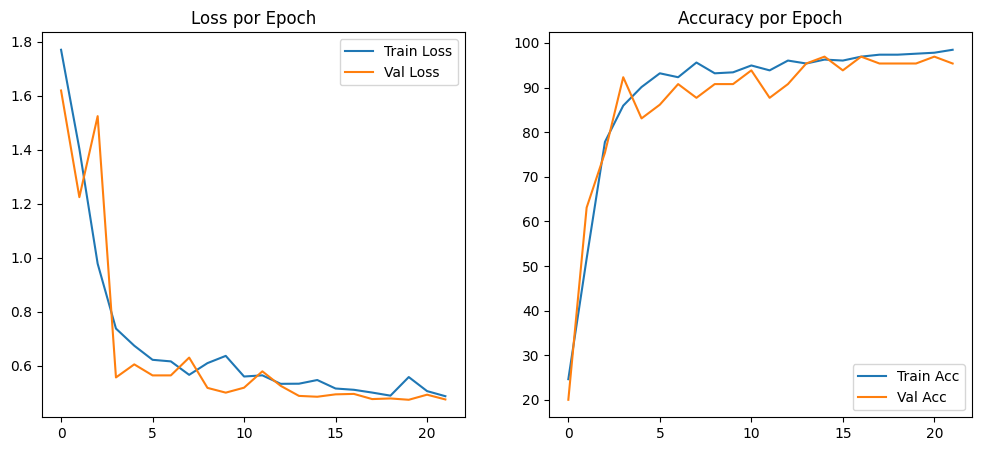

Accuracy del modelo en test: 94.66%


<Figure size 800x600 with 0 Axes>

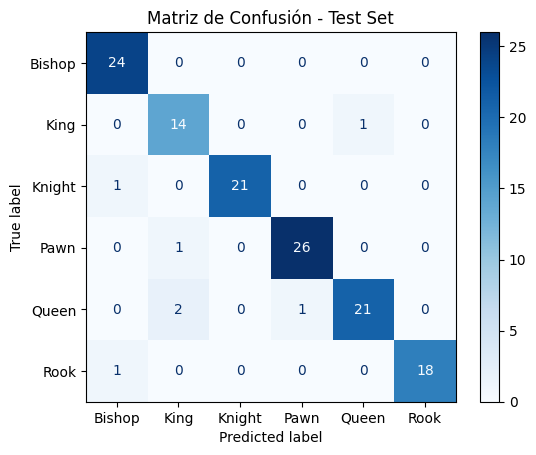

In [ ]:
import os, zipfile
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import random

from torch.utils.data import DataLoader, random_split, Subset, WeightedRandomSampler
from torchvision import datasets, transforms
from torchvision.models import resnet50, ResNet50_Weights

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from google.colab import files

def seed_everything(seed):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    np.random.seed(seed)
    random.seed(seed)

seed_everything(42)

# =============================
# SUBIR Y EXTRAER DATASET
# =============================

uploaded = files.upload()
with zipfile.ZipFile("dataset4.zip", 'r') as zip_ref:
    zip_ref.extractall("dataset4")

# =============================
# TRANSFORMACIONES
# =============================

train_transform = transforms.Compose([
    transforms.Resize((320, 320)),
    transforms.RandomResizedCrop(288, scale=(0.9, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.2),
    transforms.RandomAffine(degrees=0, translate=(0.15,0.15), scale=(0.8,1.2)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225]),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.15), ratio=(0.3, 3.3))
])

val_transform = transforms.Compose([
    transforms.Resize((320,320)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])
])

test_transform = val_transform

# =============================
# DATASETS
# =============================

full_dataset = datasets.ImageFolder(root="dataset4/dataset4")

train_size = int(0.7 * len(full_dataset))
val_size = int(0.1 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size
train_subset, val_subset, test_subset = random_split(full_dataset, [train_size, val_size, test_size])

# Etiquetas solo para train_subset para el sampler ponderado
train_labels = [full_dataset[i][1] for i in train_subset.indices]
class_counts = np.bincount(train_labels, minlength=len(full_dataset.classes))
class_weights = 1. / class_counts
sample_weights = [class_weights[label] for label in train_labels]

train_data = datasets.ImageFolder(root="dataset4/dataset4", transform=train_transform)
train_data = Subset(train_data, train_subset.indices)
val_data = datasets.ImageFolder(root="dataset4/dataset4", transform=val_transform)
val_data = Subset(val_data, val_subset.indices)
test_data = datasets.ImageFolder(root="dataset4/dataset4", transform=test_transform)
test_data = Subset(test_data, test_subset.indices)

# Sampler ponderado para train
train_sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

# =============================
# DATALOADERS
# =============================

train_loader = DataLoader(train_data, batch_size=64, sampler=train_sampler, num_workers=0)
val_loader = DataLoader(val_data, batch_size=64, shuffle=False, num_workers=0)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False, num_workers=0)

print(f"Total imágenes: {len(full_dataset)}")
print(f"Entrenamiento: {len(train_data)}")
print(f"Validación: {len(val_data)}")
print(f"Prueba: {len(test_data)}")
print(f"Clases: {full_dataset.classes}")

# =============================
# MODELO PREENTRENADO (ResNet50)
# =============================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

weights = ResNet50_Weights.DEFAULT
model = resnet50(weights=weights)

# Fine-tuning: descongelamos Solo layer3, layer4 y fc
for name, param in model.named_parameters():
    if any(layer in name for layer in ['layer3', 'layer4', 'fc']):
        param.requires_grad = True
    else:
        param.requires_grad = False

# Reemplazamos fc con dropout y más regularización
num_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(num_features, 512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, 6)
)
model = model.to(device)

# =============================
# CRITERIO, OPTIMIZADOR Y SCHEDULER
# =============================

epochs = 30
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=0.0005, weight_decay=1e-3)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)

# =============================
# ENTRENAMIENTO
# =============================

train_loss_list, val_loss_list = [], []
train_acc_list, val_acc_list = [], []
best_val_acc = 0.0
patience = 7
counter = 0

for epoch in range(epochs):
    # ----- Entrenamiento -----
    model.train()
    running_loss, correct_train, total_train = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        correct_train += (predicted == labels).sum().item()
        total_train += labels.size(0)

    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct_train / total_train

    # ----- Validación -----
    model.eval()
    val_loss, correct_val, total_val = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct_val += (predicted == labels).sum().item()
            total_val += labels.size(0)

    val_loss /= len(val_loader)
    val_acc = 100 * correct_val / total_val

    train_loss_list.append(train_loss)
    val_loss_list.append(val_loss)
    train_acc_list.append(train_acc)
    val_acc_list.append(val_acc)

    scheduler.step()

    # Early stopping
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        counter = 0
        torch.save(model.state_dict(), 'best_model.pth')
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping activado")
            break

    print(f"Epoch [{epoch+1}/{epochs}] - Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

# Cargamos el mejor modelo
model.load_state_dict(torch.load('best_model.pth'))

# =============================
# GRAFICAS DE PROGRESO
# =============================

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_loss_list, label='Train Loss')
plt.plot(val_loss_list, label='Val Loss')
plt.legend()
plt.title('Loss por Epoch')

plt.subplot(1,2,2)
plt.plot(train_acc_list, label='Train Acc')
plt.plot(val_acc_list, label='Val Acc')
plt.legend()
plt.title('Accuracy por Epoch')
plt.show()

# =============================
# EVALUACIÓN FINAL EN TEST
# =============================

model.eval()
correct_test, total_test = 0, 0
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        correct_test += (predicted == labels).sum().item()
        total_test += labels.size(0)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_acc = 100 * correct_test / total_test
print(f'Accuracy del modelo en test: {test_acc:.2f}%')

# =============================
# MATRIZ DE CONFUSIÓN
# =============================

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=full_dataset.classes)

plt.figure(figsize=(8,6))
disp.plot(cmap="Blues", values_format='d')
plt.title("Matriz de Confusión - Test Set")
plt.show()
